In [2]:
import os
import pandas as pd

# 1. Broad scan of the Kaggle input directory
input_root = '/kaggle/input'
print("--- Step 1: Scanning Kaggle Input Directory ---")
if os.path.exists(input_root) and os.listdir(input_root):
    # Dynamically find whatever folder was mounted
    mounted_folders = os.listdir(input_root)
    print(f"Found mounted folder(s): {mounted_folders}")
    
    # Construct paths based on what Kaggle mounted
    detected_dataset_name = mounted_folders[0]
    base_path = os.path.join(input_root, detected_dataset_name, 'data')
    train_path = os.path.join(base_path, 'train')
    
    print(f"Targeting Base Path: {base_path}")
    print(f"Targeting Train Path: {train_path}\n")
    
    # 2. Check and list data partitions
    if os.path.exists(base_path):
        print("✅ Success! Base data directory verified.")
        print(f"Partitions found: {os.listdir(base_path)}")
        
        # 3. Analyze Class Distribution within the Training Folder
        if os.path.exists(train_path):
            class_counts = {}
            for class_folder in os.listdir(train_path):
                folder_full_path = os.path.join(train_path, class_folder)
                if os.path.isdir(folder_full_path):
                    class_counts[class_folder] = len(os.listdir(folder_full_path))
            
            # Display the distribution cleanly using a pandas DataFrame
            df_counts = pd.DataFrame(list(class_counts.items()), columns=['Disease Class', 'Image Count'])
            print("\n--- Step 2: Training Set Distribution Breakdown ---")
            print(df_counts)
            print(f"\nTotal training images: {df_counts['Image Count'].sum()}")
        else:
            print("❌ Subfolder '/train' missing from the path setup.")
    else:
        # Fallback if the dataset root doesn't contain a 'data' subfolder
        alternative_base = os.path.join(input_root, detected_dataset_name)
        print(f"⚠️ 'data' folder not immediately found. Trying alternative path root: {alternative_base}")
        print(f"Contents: {os.listdir(alternative_base)}")
else:
    print("❌ No mounted datasets found in /kaggle/input. Please ensure the dataset is attached via the right-hand panel.")

--- Step 1: Scanning Kaggle Input Directory ---
Found mounted folder(s): ['datasets']
Targeting Base Path: /kaggle/input/datasets/data
Targeting Train Path: /kaggle/input/datasets/data/train

⚠️ 'data' folder not immediately found. Trying alternative path root: /kaggle/input/datasets
Contents: ['nikhilgurav21']


In [3]:
import os
import pandas as pd

# Define the correct structural path based on your scan
base_path = '/kaggle/input/datasets/nikhilgurav21/nail-disease-detection-dataset/data'

# Let's verify and display the actual directories
if os.path.exists(base_path):
    print("✅ System Connection Established! Paths verified.")
    print(f"Data Splitting Partitions: {os.listdir(base_path)}")
    
    train_path = os.path.join(base_path, 'train')
    
    # Analyze Class Distribution within the Training Folder
    if os.path.exists(train_path):
        class_counts = {}
        for class_folder in os.listdir(train_path):
            folder_full_path = os.path.join(train_path, class_folder)
            if os.path.isdir(folder_full_path):
                class_counts[class_folder] = len(os.listdir(folder_full_path))
        
        # Display cleanly using a pandas DataFrame
        df_counts = pd.DataFrame(list(class_counts.items()), columns=['Disease Class', 'Image Count'])
        print("\n--- Training Set Distribution Breakdown ---")
        print(df_counts)
        print(f"\nTotal training images available: {df_counts['Image Count'].sum()}")
else:
    print("❌ Path connection failed. Let's do a direct look into the folder:")
    fallback_root = '/kaggle/input/datasets/nikhilgurav21'
    print("Contents under nikhilgurav21:", os.listdir(fallback_root))

✅ System Connection Established! Paths verified.
Data Splitting Partitions: ['validation', 'train']

--- Training Set Distribution Breakdown ---
                Disease Class  Image Count
0                 blue_finger          603
1  Acral_Lentiginous_Melanoma          735
2                     pitting          639
3             Onychogryphosis          677
4                    clubbing          767
5                Healthy_Nail          323

Total training images available: 3744


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np

# 1. Establish computing device (Using Kaggle's GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training pipeline will run on: {device}")

# 2. Define Image Paths
base_path = '/kaggle/input/datasets/nikhilgurav21/nail-disease-detection-dataset/data'
train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'validation')

# 3. Augmentation & Normalization Pipeline
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 4. Create PyTorch Datasets and DataLoaders
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=4),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=4)
}

# 5. Compute Inverse Class Weights to fight imbalance
class_counts = [323, 735, 603, 767, 677, 639] # Matches your exact output order
total_samples = sum(class_counts)
# Inverse frequency formula
class_weights = [total_samples / (len(class_counts) * c) for c in class_counts]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("✅ Data pipelines successfully compiled!")
print(f"Classes map directly to directories: {image_datasets['train'].classes}")

🚀 Training pipeline will run on: cuda
✅ Data pipelines successfully compiled!
Classes map directly to directories: ['Acral_Lentiginous_Melanoma', 'Healthy_Nail', 'Onychogryphosis', 'blue_finger', 'clubbing', 'pitting']


In [5]:
import copy
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

# 1. Initialize Pre-trained MobileNetV3-Large Backbone (Using the updated weights API)
print("📥 Fetching pre-trained MobileNetV3-Large...")
weights = MobileNet_V3_Large_Weights.DEFAULT
model = mobilenet_v3_large(weights=weights)

# 2. Freeze Backbone Layers (Phase 1: Warm up the head)
for param in model.parameters():
    param.requires_grad = False

# 3. Replace Classifier Head for our 6 specific targets
num_features = model.classifier[0].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 6) 
)
model = model.to(device)

# 4. Use AdamW Optimizer and Weighted Loss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)

# 5. Variables to track the absolute BEST model configurations
num_epochs = 15
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("\n--- Initiating Phase 1: Classifier Head Optimization (15 Epochs) ---")

for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        print(f"Epoch {epoch+1}/{num_epochs} | {phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        # Deep save checkpoint if this epoch yields the highest validation accuracy
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"🌟 New best validation accuracy reached! ({best_acc:.4f}) - Tracking weights.")

# Load back the absolute optimal weights configuration before saving to disk
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_nail_classifier.pth')

print(f"\n🎉 Training finalized! Optimal validation accuracy: {best_acc:.4f}")
print("The best weights configuration has been permanently saved as 'best_nail_classifier.pth'.")

📥 Fetching pre-trained MobileNetV3-Large...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 137MB/s] 



--- Initiating Phase 1: Classifier Head Optimization (15 Epochs) ---
Epoch 1/15 | Train Loss: 0.9894 Acc: 0.5871
Epoch 1/15 | Val Loss: 0.7161 Acc: 0.7802
🌟 New best validation accuracy reached! (0.7802) - Tracking weights.
Epoch 2/15 | Train Loss: 0.6926 Acc: 0.7236
Epoch 2/15 | Val Loss: 0.4519 Acc: 0.8571
🌟 New best validation accuracy reached! (0.8571) - Tracking weights.
Epoch 3/15 | Train Loss: 0.6199 Acc: 0.7500
Epoch 3/15 | Val Loss: 0.5061 Acc: 0.8132
Epoch 4/15 | Train Loss: 0.5788 Acc: 0.7754
Epoch 4/15 | Val Loss: 0.4100 Acc: 0.8462
Epoch 5/15 | Train Loss: 0.5443 Acc: 0.7764
Epoch 5/15 | Val Loss: 0.4340 Acc: 0.8791
🌟 New best validation accuracy reached! (0.8791) - Tracking weights.
Epoch 6/15 | Train Loss: 0.5180 Acc: 0.7983
Epoch 6/15 | Val Loss: 0.3773 Acc: 0.8462
Epoch 7/15 | Train Loss: 0.4901 Acc: 0.8106
Epoch 7/15 | Val Loss: 0.3934 Acc: 0.8571
Epoch 8/15 | Train Loss: 0.4691 Acc: 0.8160
Epoch 8/15 | Val Loss: 0.3644 Acc: 0.8462
Epoch 9/15 | Train Loss: 0.4897 Acc

In [6]:
import copy

# 1. Unfreeze all layers of the model for deep fine-tuning
print("🔓 Unfreezing backbone layers...")
for param in model.parameters():
    param.requires_grad = True

# 2. Lower the learning rate drastically to preserve pre-trained features
# We track the base parameters with 1e-5 and the head with 1e-4 for stable fine-tuning
optimizer_fine = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-2)

# 3. Setup tracking variables (Starting from your previous best baseline)
fine_tune_epochs = 10
print(f"Starting Phase 2 from baseline Best Accuracy: {best_acc:.4f}")

print("\n--- Initiating Phase 2: Full Fine-Tuning (10 Epochs) ---")

for epoch in range(fine_tune_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_fine.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer_fine.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        print(f"Fine-Tune Epoch {epoch+1}/{fine_tune_epochs} | {phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        # Track and save if Phase 2 beats the previous overall best accuracy
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"🔥 Milestone! New absolute best accuracy reached: ({best_acc:.4f}) - Updating weights.")

# 4. Load the optimal weights and overwrite the checkpoint file
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_nail_classifier.pth')

print(f"\n🎉 Fine-tuning completed! Final peak validation accuracy: {best_acc:.4f}")
print("The updated optimal weights are saved as 'best_nail_classifier.pth' in /kaggle/working/.")

🔓 Unfreezing backbone layers...
Starting Phase 2 from baseline Best Accuracy: 0.8901

--- Initiating Phase 2: Full Fine-Tuning (10 Epochs) ---
Fine-Tune Epoch 1/10 | Train Loss: 0.3178 Acc: 0.8710
Fine-Tune Epoch 1/10 | Val Loss: 0.3348 Acc: 0.8901
Fine-Tune Epoch 2/10 | Train Loss: 0.2756 Acc: 0.8886
Fine-Tune Epoch 2/10 | Val Loss: 0.3224 Acc: 0.9011
🔥 Milestone! New absolute best accuracy reached: (0.9011) - Updating weights.
Fine-Tune Epoch 3/10 | Train Loss: 0.2437 Acc: 0.9033
Fine-Tune Epoch 3/10 | Val Loss: 0.3108 Acc: 0.9121
🔥 Milestone! New absolute best accuracy reached: (0.9121) - Updating weights.
Fine-Tune Epoch 4/10 | Train Loss: 0.2236 Acc: 0.9100
Fine-Tune Epoch 4/10 | Val Loss: 0.3119 Acc: 0.9011
Fine-Tune Epoch 5/10 | Train Loss: 0.1962 Acc: 0.9207
Fine-Tune Epoch 5/10 | Val Loss: 0.2881 Acc: 0.9121
Fine-Tune Epoch 6/10 | Train Loss: 0.1750 Acc: 0.9279
Fine-Tune Epoch 6/10 | Val Loss: 0.2697 Acc: 0.9121
Fine-Tune Epoch 7/10 | Train Loss: 0.1659 Acc: 0.9279
Fine-Tune E

=== CLINICAL CLASSIFICATION REPORT ===
                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma       0.94      0.94      0.94        18
              Healthy_Nail       1.00      1.00      1.00        20
           Onychogryphosis       1.00      1.00      1.00        12
               blue_finger       0.75      1.00      0.86         9
                  clubbing       1.00      0.69      0.81        16
                   pitting       0.89      1.00      0.94        16

                  accuracy                           0.93        91
                 macro avg       0.93      0.94      0.93        91
              weighted avg       0.94      0.93      0.93        91



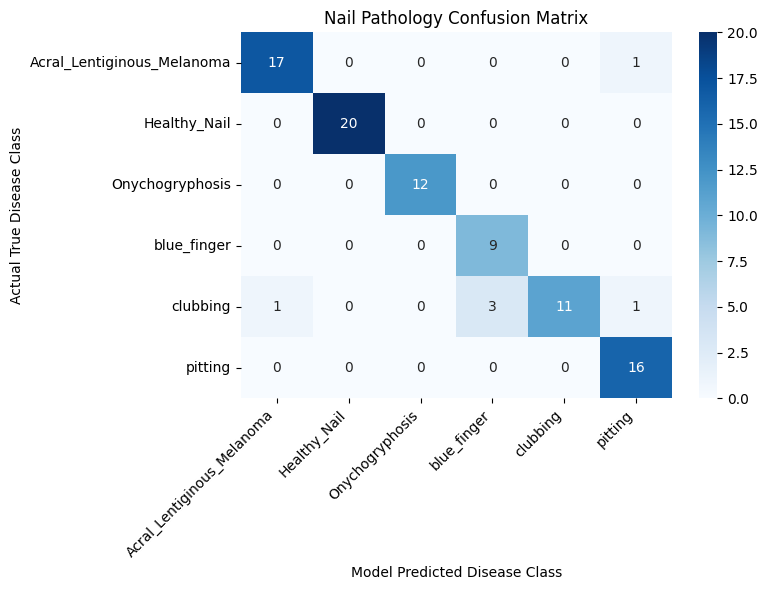

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Put model into evaluation mode
model.eval()

all_preds = []
all_labels = []

# 2. Turn off gradient tracking to save memory and accelerate inference
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Collect predictions and true labels back to the CPU
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Get the readable class names from our dataset
class_names = image_datasets['val'].classes

# 4. Generate the Text-Based Classification Report (Precision, Recall, F1)
print("=== CLINICAL CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 5. Compute and Plot the Visual Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Nail Pathology Confusion Matrix')
plt.ylabel('Actual True Disease Class')
plt.xlabel('Model Predicted Disease Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()